# White House Visitor Logs <br> Complete Medallion Architecture with DuckDB

This notebook is a **complete teaching notebook** that connects:

- EDA findings
- Bronze → Silver → Gold Medallion Architecture
- dimensional warehouse design
- visual analytics
- 12 OLAP queries
- visitor behavioral analytics
- meeting network analysis

## Why certain columns are dropped in Silver

From the EDA notebook, these columns were identified as low-value for the behavioral warehouse:

- `CALLER_ROOM` — 100% null
- `BDGNBR` — mostly null and operational/security-oriented
- `POA` — mostly null and access-control oriented
- `TOA` — mostly null and access-control oriented
- `TOD` — mostly null and departure-log oriented
- `POD` — mostly null and departure-log oriented

These are intentionally excluded from Silver so the cleaned model focuses on:
- who visited
- whom they visited
- when the visit happened
- where it happened
- event description and group size


## 0. Setup


In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams['figure.figsize'] = (10, 6)

DATA_PATH = Path('whitehouse_waves-2016_12.csv')

con = duckdb.connect()
con.execute('PRAGMA threads=4')


## 1. Bronze Layer — raw ingestion

        Bronze preserves the source data as 
        close to the original export as possible.
        We ingest all columns as text and allow 
        a tiny number of malformed rows to be skipped.


In [2]:
con.execute('DROP TABLE IF EXISTS bronze_visitors')

con.execute(f"""
CREATE TABLE bronze_visitors AS
SELECT *
FROM read_csv_auto(
    '{DATA_PATH.as_posix()}',
    header = true,
    sample_size = -1,
    ignore_errors = true,
    all_varchar = true
)
""")

bronze_profile = con.execute("""
SELECT
    COUNT(*) AS row_count,
    COUNT(DISTINCT UIN) AS distinct_uin,
    COUNT(DISTINCT Release_Date) AS distinct_release_dates
FROM bronze_visitors
""").df()

bronze_profile


,row_count,distinct_uin,distinct_release_dates
0,970498,96295,12


In [3]:
con.execute("DESCRIBE bronze_visitors").df()


,column_name,column_type,null,key,default,extra
0,NAMELAST,VARCHAR,YES,None,None,None
1,NAMEFIRST,VARCHAR,YES,None,None,None
2,NAMEMID,VARCHAR,YES,None,None,None
3,UIN,VARCHAR,YES,None,None,None
4,BDGNBR,VARCHAR,YES,None,None,None
5,ACCESS_TYPE,VARCHAR,YES,None,None,None
6,TOA,VARCHAR,YES,None,None,None
7,POA,VARCHAR,YES,None,None,None
8,TOD,VARCHAR,YES,None,None,None
9,POD,VARCHAR,YES,None,None,None


## 2. Silver Layer — cleaned event records

Silver does the following:
- removes duplicate rows with `SELECT DISTINCT`
- converts text dates into timestamps
- standardizes visitor and visitee names
- keeps the analytically meaningful columns
- drops mostly-null and operational columns identified by EDA
- maps missing identities to warehouse-friendly labels where needed


In [4]:
con.execute('DROP TABLE IF EXISTS silver_visits')

con.execute("""
CREATE TABLE silver_visits AS
SELECT DISTINCT
    NULLIF(TRIM(UIN), '') AS uin,
    TRIM(NAMEFIRST) AS visitor_first_name,
    TRIM(NAMELAST) AS visitor_last_name,
    NULLIF(TRIM(NAMEMID), '') AS visitor_middle_name,
    CASE
        WHEN TRIM(NAMEFIRST) = '/' OR TRIM(NAMELAST) = '/' THEN 'UNKNOWN_VISITOR'
        ELSE UPPER(TRIM(NAMEFIRST) || ' ' || TRIM(NAMELAST))
    END AS visitor_name,
    COALESCE(
        TRY_STRPTIME(APPT_MADE_DATE, '%m/%d/%Y %H:%M'),
        TRY_STRPTIME(APPT_MADE_DATE, '%m/%d/%Y')
    ) AS appt_made_ts,
    COALESCE(
        TRY_STRPTIME(APPT_START_DATE, '%m/%d/%Y %H:%M'),
        TRY_STRPTIME(APPT_START_DATE, '%m/%d/%Y')
    ) AS visit_start_ts,
    COALESCE(
        TRY_STRPTIME(APPT_END_DATE, '%m/%d/%Y %H:%M'),
        TRY_STRPTIME(APPT_END_DATE, '%m/%d/%Y')
    ) AS visit_end_ts,
    CAST(NULLIF(TRIM(Total_People), '') AS INTEGER) AS total_people,
    NULLIF(TRIM(ACCESS_TYPE), '') AS access_type,
    NULLIF(TRIM(MEETING_LOC), '') AS meeting_loc,
    NULLIF(TRIM(MEETING_ROOM), '') AS meeting_room,
    NULLIF(TRIM(DESCRIPTION), '') AS description,
    NULLIF(TRIM(visitee_namefirst), '') AS visitee_first_name,
    NULLIF(TRIM(visitee_namelast), '') AS visitee_last_name,
    CASE
        WHEN COALESCE(TRIM(visitee_namefirst), '') = '' AND COALESCE(TRIM(visitee_namelast), '') = '' THEN 'UNKNOWN_VISITEE'
        WHEN COALESCE(TRIM(visitee_namelast), '') = '' THEN UPPER(TRIM(visitee_namefirst))
        WHEN COALESCE(TRIM(visitee_namefirst), '') = '' THEN UPPER(TRIM(visitee_namelast))
        ELSE UPPER(TRIM(visitee_namefirst) || ' ' || TRIM(visitee_namelast))
    END AS visitee_name,
    TRY_STRPTIME(Release_Date, '%m/%d/%Y') AS release_date
FROM bronze_visitors
WHERE COALESCE(
        TRY_STRPTIME(APPT_START_DATE, '%m/%d/%Y %H:%M'),
        TRY_STRPTIME(APPT_START_DATE, '%m/%d/%Y')
      ) IS NOT NULL
  AND COALESCE(
        TRY_STRPTIME(APPT_END_DATE, '%m/%d/%Y %H:%M'),
        TRY_STRPTIME(APPT_END_DATE, '%m/%d/%Y')
      ) IS NOT NULL
""")

silver_quality = con.execute("""
SELECT
    COUNT(*) AS row_count,
    COUNT(DISTINCT uin) AS distinct_uin,
    SUM(CASE WHEN visitor_name = 'UNKNOWN_VISITOR' THEN 1 ELSE 0 END) AS unknown_visitor_rows,
    SUM(CASE WHEN visitee_name = 'UNKNOWN_VISITEE' THEN 1 ELSE 0 END) AS unknown_visitee_rows,
    SUM(CASE WHEN total_people IS NULL THEN 1 ELSE 0 END) AS missing_total_people
FROM silver_visits
""").df()

silver_quality


,row_count,distinct_uin,unknown_visitor_rows,unknown_visitee_rows,missing_total_people
0,968050,96295,0.0,4182.0,4182.0


In [5]:
con.execute("""
SELECT uin, visitor_name, visitee_name, visit_start_ts, visit_end_ts, total_people, meeting_loc, meeting_room, description
FROM silver_visits
LIMIT 10
""").df()


,uin,visitor_name,visitee_name,visit_start_ts,visit_end_ts,total_people,meeting_loc,meeting_room,description
0,U77405,VALERIA PERSON,VISITORS OFFICE,2016-03-04 09:00:00,2016-03-04 23:59:00,268,WH,EW TOUR,EW Tour Must enter through Sherman Park
1,U77405,KEISHA ROBINSON,VISITORS OFFICE,2016-03-04 09:00:00,2016-03-04 23:59:00,268,WH,EW TOUR,EW Tour Must enter through Sherman Park
2,U77405,IRMA SELBY,VISITORS OFFICE,2016-03-04 09:00:00,2016-03-04 23:59:00,268,WH,EW TOUR,EW Tour Must enter through Sherman Park
3,U77405,CONSTANCE SUMMERS,VISITORS OFFICE,2016-03-04 09:00:00,2016-03-04 23:59:00,268,WH,EW TOUR,EW Tour Must enter through Sherman Park
4,U77405,SEAN WALKER,VISITORS OFFICE,2016-03-04 09:00:00,2016-03-04 23:59:00,268,WH,EW TOUR,EW Tour Must enter through Sherman Park
5,U81260,VALERIE EARNSHAW,DOUGLAS BROOKS,2016-03-04 09:00:00,2016-03-04 23:59:00,37,OEOB,430,None
6,U82449,ERICA ZUCEC,VISITORS OFFICE,2016-03-04 09:29:00,2016-03-04 23:59:00,1,WH,EW TOUR,EW Tour Must enter through Sherman Park dob ...
7,U81604,RAQUELVIVIAN MUNT,VISITORS OFFICE,2016-03-04 09:30:00,2016-03-04 23:59:00,17,WH,EW TOUR,EW Tour Must enter through Sherman Park
8,U81407,ASHLYNNE PROFIT,VISITORS OFFICE,2016-03-04 09:30:00,2016-03-04 23:59:00,3,WH,EW TOUR,EW Tour Must enter through Sherman Park
9,U81434,CAMERON RUBIN,VISITORS OFFICE,2016-03-04 09:30:00,2016-03-04 23:59:00,70,WH,EW TOUR,EW Tour Must enter through Sherman Park


## 3. Why Medallion matters — Bronze vs Silver comparison

    This is the single most important teaching 
    visualization in the notebook.

    It compares the same metric in Bronze and Silver 
    so students can see that raw data and analytical 
    data are not the same.


In [6]:
bronze_df = con.execute("""
SELECT
    COALESCE(
        TRY_STRPTIME(APPT_START_DATE, '%m/%d/%Y %H:%M'),
        TRY_STRPTIME(APPT_START_DATE, '%m/%d/%Y')
    ) AS ts
FROM bronze_visitors
WHERE APPT_START_DATE IS NOT NULL
""").df()

bronze_df = bronze_df.dropna()
bronze_df['date'] = bronze_df['ts'].dt.date
bronze_daily = bronze_df.groupby('date').size().reset_index(name='bronze_rows')

silver_df = con.execute("SELECT visit_start_ts FROM silver_visits").df()
silver_df = silver_df.dropna()
silver_df['date'] = silver_df['visit_start_ts'].dt.date
silver_daily = silver_df.groupby('date').size().reset_index(name='silver_rows')

compare = bronze_daily.merge(silver_daily, on='date', how='inner')
compare.head()


,date,bronze_rows,silver_rows
0,2015-10-01,3898,3898
1,2015-10-02,4848,4836
2,2015-10-03,3934,3926
3,2015-10-04,476,474
4,2015-10-05,1147,1144


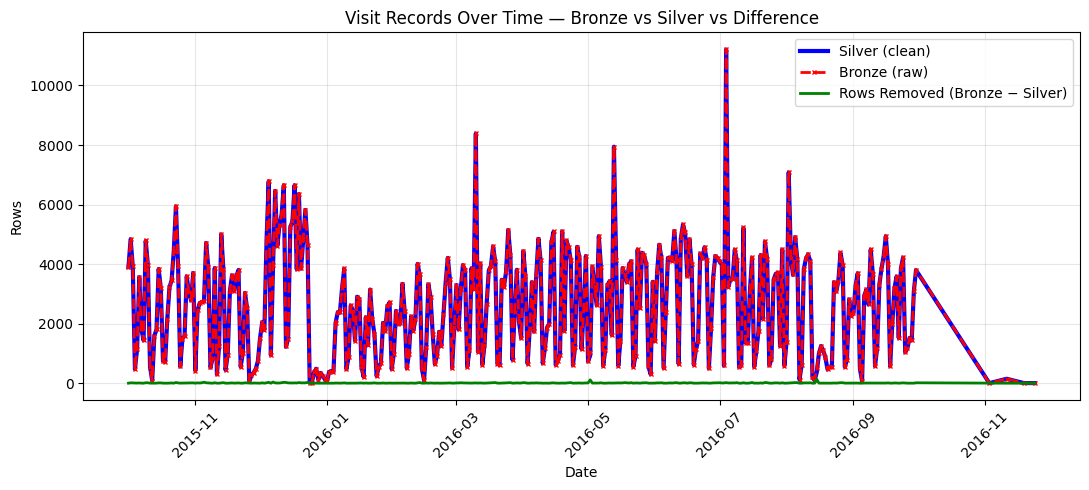

In [13]:
compare["difference"] = compare["bronze_rows"] - compare["silver_rows"]

plt.figure(figsize=(11,5))

# Silver (clean)
plt.plot(
    compare['date'],
    compare['silver_rows'],
    color='blue',
    linewidth=3,
    label='Silver (clean)'
)

# Bronze (raw)
plt.plot(
    compare['date'],
    compare['bronze_rows'],
    color='red',
    linestyle='--',
    linewidth=2,
    marker='x',
    markersize=3,
    label='Bronze (raw)'
)

# Difference
plt.plot(
    compare['date'],
    compare['difference'],
    color='green',
    linewidth=2,
    label='Rows Removed (Bronze − Silver)'
)

plt.title("Visit Records Over Time — Bronze vs Silver vs Difference")
plt.xlabel("Date")
plt.ylabel("Rows")

plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 4. Focused Silver EDA for warehouse design


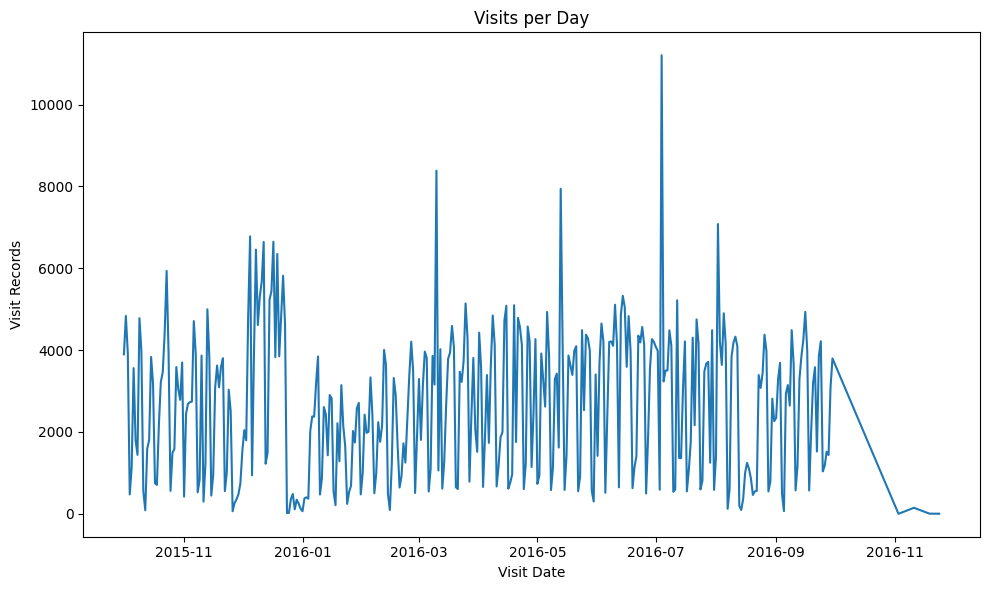

In [14]:
visits_by_day = con.execute("""
SELECT CAST(visit_start_ts AS DATE) AS visit_date, COUNT(*) AS visits
FROM silver_visits
GROUP BY 1
ORDER BY 1
""").df()

plt.figure()
plt.plot(visits_by_day['visit_date'], visits_by_day['visits'])
plt.title('Visits per Day')
plt.xlabel('Visit Date')
plt.ylabel('Visit Records')
plt.tight_layout()
plt.show()


In [15]:
top_locations = con.execute("""
SELECT COALESCE(meeting_loc, 'UNKNOWN') AS meeting_loc, COUNT(*) AS visits
FROM silver_visits
GROUP BY 1
ORDER BY visits DESC
LIMIT 15
""").df()

top_locations


,meeting_loc,visits
0,WH,707312
1,OEOB,239161
2,NEOB,17395
3,UNKNOWN,2592
4,VPR,1590


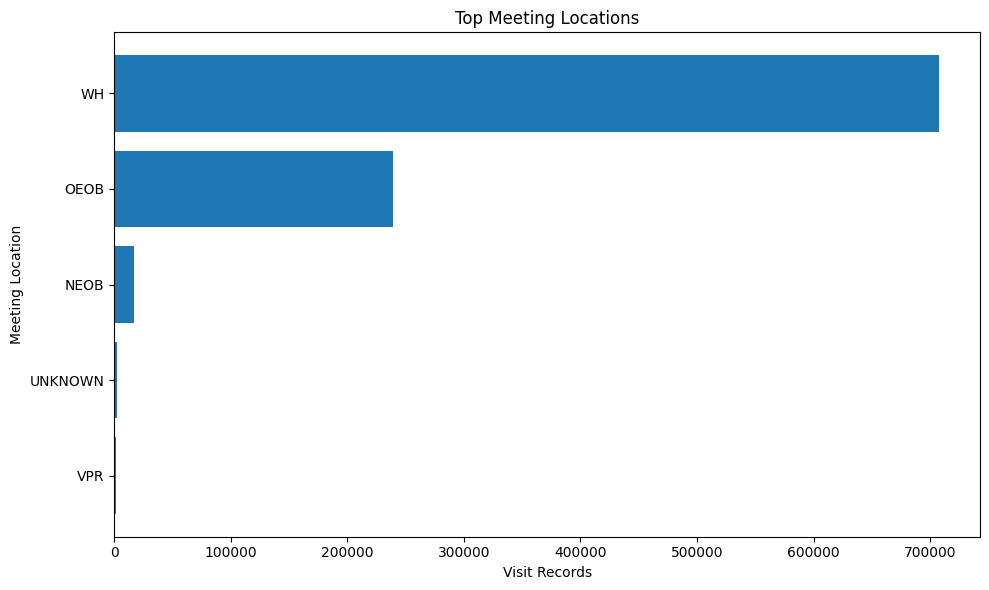

In [16]:
plt.figure()
plt.barh(top_locations['meeting_loc'][::-1], top_locations['visits'][::-1])
plt.title('Top Meeting Locations')
plt.xlabel('Visit Records')
plt.ylabel('Meeting Location')
plt.tight_layout()
plt.show()


In [17]:
top_visitees = con.execute("""
SELECT visitee_name, COUNT(*) AS visits
FROM silver_visits
GROUP BY 1
ORDER BY visits DESC
LIMIT 20
""").df()

top_visitees


,visitee_name,visits
0,VISITORS OFFICE,429703
1,VISITORSOFFICE WAVES,44007
2,POTUS,33488
3,POTUS/FLOTUS,15163
4,RUTH BRYANT,13938
5,OLIVIA ONEIL,13140
6,JARED THOMPSON,11575
7,POTUS /,10884
8,COLLIN BURTON,9646
9,MATTHEW MEGAN,7915


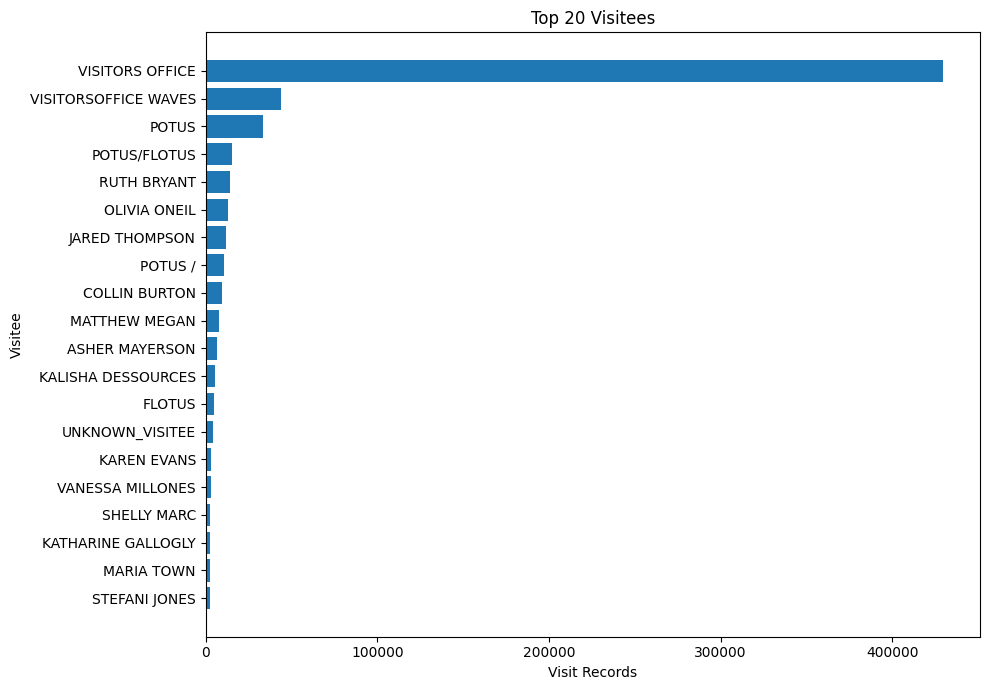

In [18]:
plt.figure(figsize=(10, 7))
plt.barh(top_visitees['visitee_name'][::-1], top_visitees['visits'][::-1])
plt.title('Top 20 Visitees')
plt.xlabel('Visit Records')
plt.ylabel('Visitee')
plt.tight_layout()
plt.show()


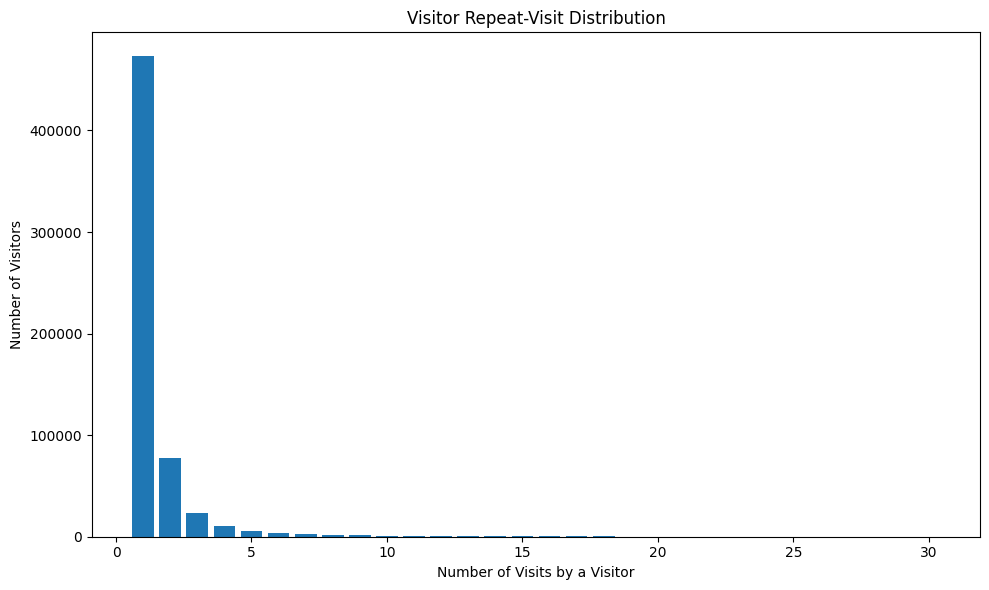

In [19]:
visitor_frequency = con.execute("""
SELECT visit_count, COUNT(*) AS number_of_visitors
FROM (
    SELECT visitor_name, COUNT(*) AS visit_count
    FROM silver_visits
    GROUP BY 1
) t
GROUP BY 1
ORDER BY 1
LIMIT 30
""").df()

plt.figure()
plt.bar(visitor_frequency['visit_count'], visitor_frequency['number_of_visitors'])
plt.title('Visitor Repeat-Visit Distribution')
plt.xlabel('Number of Visits by a Visitor')
plt.ylabel('Number of Visitors')
plt.tight_layout()
plt.show()


## 5. Gold Layer — dimensional warehouse

We build a small star-like warehouse:
- `dim_date`
- `dim_visitor`
- `dim_visitee`
- `dim_location`
- `dim_event`
- `fact_visit`
- `fact_visitor_daily`
- `fact_pair_daily`


In [20]:
con.execute('DROP TABLE IF EXISTS dim_date')
con.execute("""
CREATE TABLE dim_date AS
WITH dates AS (
    SELECT DISTINCT CAST(visit_start_ts AS DATE) AS date_key
    FROM silver_visits
)
SELECT
    date_key,
    EXTRACT(YEAR FROM date_key) AS year_num,
    EXTRACT(MONTH FROM date_key) AS month_num,
    EXTRACT(DAY FROM date_key) AS day_num,
    STRFTIME(date_key, '%Y-%m') AS year_month,
    STRFTIME(date_key, '%A') AS weekday_name
FROM dates
ORDER BY date_key
""")

con.execute('DROP TABLE IF EXISTS dim_visitor')
con.execute("""
CREATE TABLE dim_visitor AS
SELECT
    ROW_NUMBER() OVER (ORDER BY visitor_name, COALESCE(uin, '')) AS visitor_key,
    uin,
    visitor_name,
    visitor_first_name,
    visitor_middle_name,
    visitor_last_name
FROM (
    SELECT DISTINCT uin, visitor_name, visitor_first_name, visitor_middle_name, visitor_last_name
    FROM silver_visits
) t
""")

con.execute('DROP TABLE IF EXISTS dim_visitee')
con.execute("""
CREATE TABLE dim_visitee AS
SELECT
    ROW_NUMBER() OVER (ORDER BY visitee_name) AS visitee_key,
    visitee_name,
    visitee_first_name,
    visitee_last_name
FROM (
    SELECT DISTINCT visitee_name, visitee_first_name, visitee_last_name
    FROM silver_visits
) t
""")

con.execute('DROP TABLE IF EXISTS dim_location')
con.execute("""
CREATE TABLE dim_location AS
SELECT
    ROW_NUMBER() OVER (ORDER BY COALESCE(meeting_loc, 'UNKNOWN'), COALESCE(meeting_room, 'UNKNOWN')) AS location_key,
    COALESCE(meeting_loc, 'UNKNOWN') AS meeting_loc,
    COALESCE(meeting_room, 'UNKNOWN') AS meeting_room
FROM (
    SELECT DISTINCT meeting_loc, meeting_room
    FROM silver_visits
) t
""")

con.execute('DROP TABLE IF EXISTS dim_event')
con.execute("""
CREATE TABLE dim_event AS
SELECT
    ROW_NUMBER() OVER (ORDER BY COALESCE(description, 'UNKNOWN')) AS event_key,
    COALESCE(description, 'UNKNOWN') AS description
FROM (
    SELECT DISTINCT description
    FROM silver_visits
) t
""")

con.execute('DROP TABLE IF EXISTS fact_visit')
con.execute("""
CREATE TABLE fact_visit AS
SELECT
    ROW_NUMBER() OVER () AS visit_fact_key,
    d.date_key,
    v.visitor_key,
    vt.visitee_key,
    l.location_key,
    e.event_key,
    s.visit_start_ts,
    s.visit_end_ts,
    DATE_DIFF('minute', s.visit_start_ts, s.visit_end_ts) AS visit_duration_minutes,
    s.total_people,
    s.access_type
FROM silver_visits s
JOIN dim_date d
  ON CAST(s.visit_start_ts AS DATE) = d.date_key
JOIN dim_visitor v
  ON s.visitor_name = v.visitor_name
 AND COALESCE(s.uin, '') = COALESCE(v.uin, '')
JOIN dim_visitee vt
  ON s.visitee_name = vt.visitee_name
JOIN dim_location l
  ON COALESCE(s.meeting_loc, 'UNKNOWN') = l.meeting_loc
 AND COALESCE(s.meeting_room, 'UNKNOWN') = l.meeting_room
JOIN dim_event e
  ON COALESCE(s.description, 'UNKNOWN') = e.description
""")

con.execute('DROP TABLE IF EXISTS fact_visitor_daily')
con.execute("""
CREATE TABLE fact_visitor_daily AS
SELECT
    date_key,
    visitor_key,
    COUNT(*) AS visit_records,
    SUM(COALESCE(total_people, 0)) AS people_sum,
    AVG(COALESCE(visit_duration_minutes, 0)) AS avg_duration_minutes
FROM fact_visit
GROUP BY 1, 2
""")

con.execute('DROP TABLE IF EXISTS fact_pair_daily')
con.execute("""
CREATE TABLE fact_pair_daily AS
SELECT
    date_key,
    visitor_key,
    visitee_key,
    COUNT(*) AS visit_records,
    SUM(COALESCE(total_people, 0)) AS people_sum
FROM fact_visit
GROUP BY 1, 2, 3
""")


In [21]:
warehouse_counts = pd.DataFrame({
    'table_name': [
        'dim_date', 'dim_visitor', 'dim_visitee', 'dim_location', 'dim_event',
        'fact_visit', 'fact_visitor_daily', 'fact_pair_daily'
    ],
    'row_count': [
        con.execute('SELECT COUNT(*) FROM dim_date').fetchone()[0],
        con.execute('SELECT COUNT(*) FROM dim_visitor').fetchone()[0],
        con.execute('SELECT COUNT(*) FROM dim_visitee').fetchone()[0],
        con.execute('SELECT COUNT(*) FROM dim_location').fetchone()[0],
        con.execute('SELECT COUNT(*) FROM dim_event').fetchone()[0],
        con.execute('SELECT COUNT(*) FROM fact_visit').fetchone()[0],
        con.execute('SELECT COUNT(*) FROM fact_visitor_daily').fetchone()[0],
        con.execute('SELECT COUNT(*) FROM fact_pair_daily').fetchone()[0],
    ]
})

warehouse_counts


,table_name,row_count
0,dim_date,370
1,dim_visitor,967538
2,dim_visitee,6505
3,dim_location,2592
4,dim_event,2687
5,fact_visit,2754125
6,fact_visitor_daily,967846
7,fact_pair_daily,2737100


## 6. Behavioral analytics visualizations


In [22]:
monthly_visits = con.execute("""
SELECT d.year_month, COUNT(*) AS visits
FROM fact_visit f
JOIN dim_date d ON f.date_key = d.date_key
GROUP BY 1
ORDER BY 1
""").df()

monthly_visits


,year_month,visits
0,2015-10,243459
1,2015-11,190343
2,2015-12,294085
3,2016-01,150648
4,2016-02,165141
5,2016-03,278094
6,2016-04,213297
7,2016-05,140425
8,2016-06,333081
9,2016-07,281661


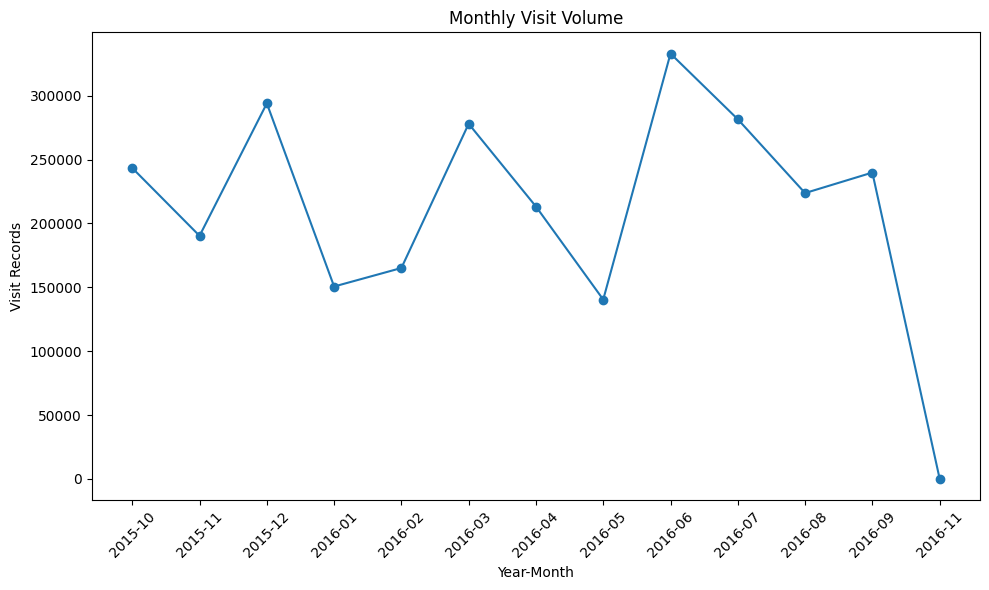

In [23]:
plt.figure()
plt.plot(monthly_visits['year_month'], monthly_visits['visits'], marker='o')
plt.title('Monthly Visit Volume')
plt.xlabel('Year-Month')
plt.ylabel('Visit Records')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


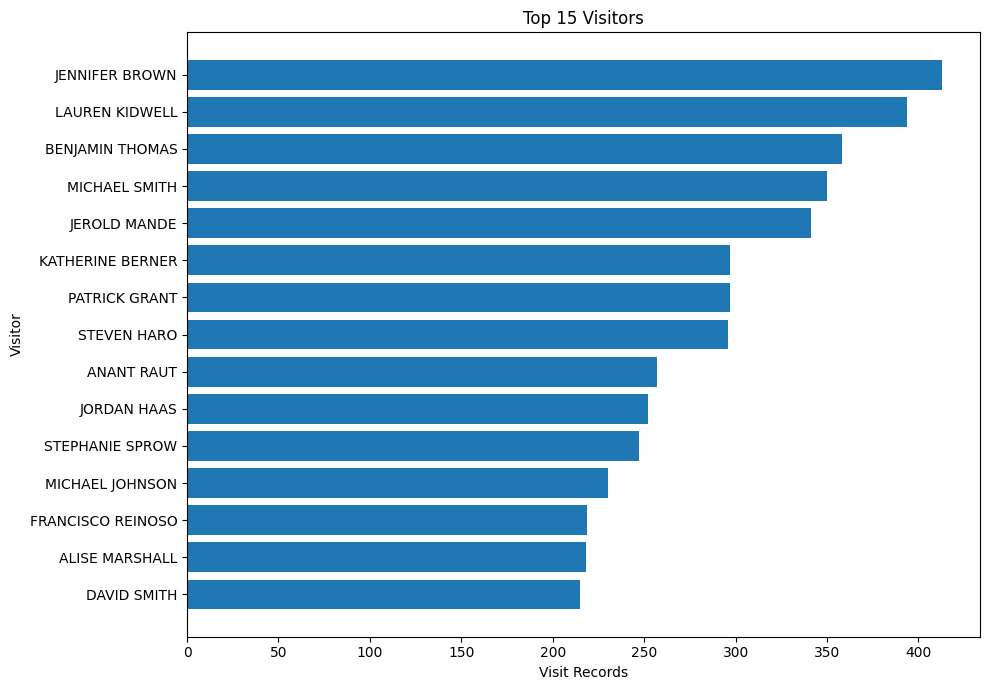

In [24]:
top_15_visitors = con.execute("""
SELECT v.visitor_name, COUNT(*) AS visits
FROM fact_visit f
JOIN dim_visitor v ON f.visitor_key = v.visitor_key
GROUP BY 1
ORDER BY visits DESC
LIMIT 15
""").df()

plt.figure(figsize=(10, 7))
plt.barh(top_15_visitors['visitor_name'][::-1], top_15_visitors['visits'][::-1])
plt.title('Top 15 Visitors')
plt.xlabel('Visit Records')
plt.ylabel('Visitor')
plt.tight_layout()
plt.show()


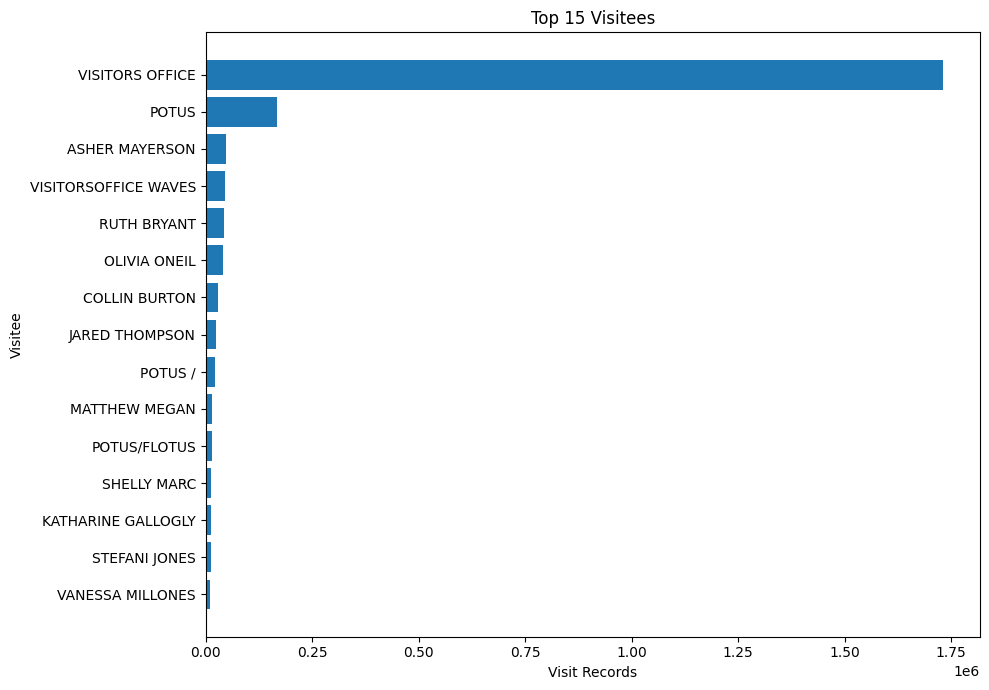

In [25]:
top_15_visitees = con.execute("""
SELECT vt.visitee_name, COUNT(*) AS visits
FROM fact_visit f
JOIN dim_visitee vt ON f.visitee_key = vt.visitee_key
GROUP BY 1
ORDER BY visits DESC
LIMIT 15
""").df()

plt.figure(figsize=(10, 7))
plt.barh(top_15_visitees['visitee_name'][::-1], top_15_visitees['visits'][::-1])
plt.title('Top 15 Visitees')
plt.xlabel('Visit Records')
plt.ylabel('Visitee')
plt.tight_layout()
plt.show()


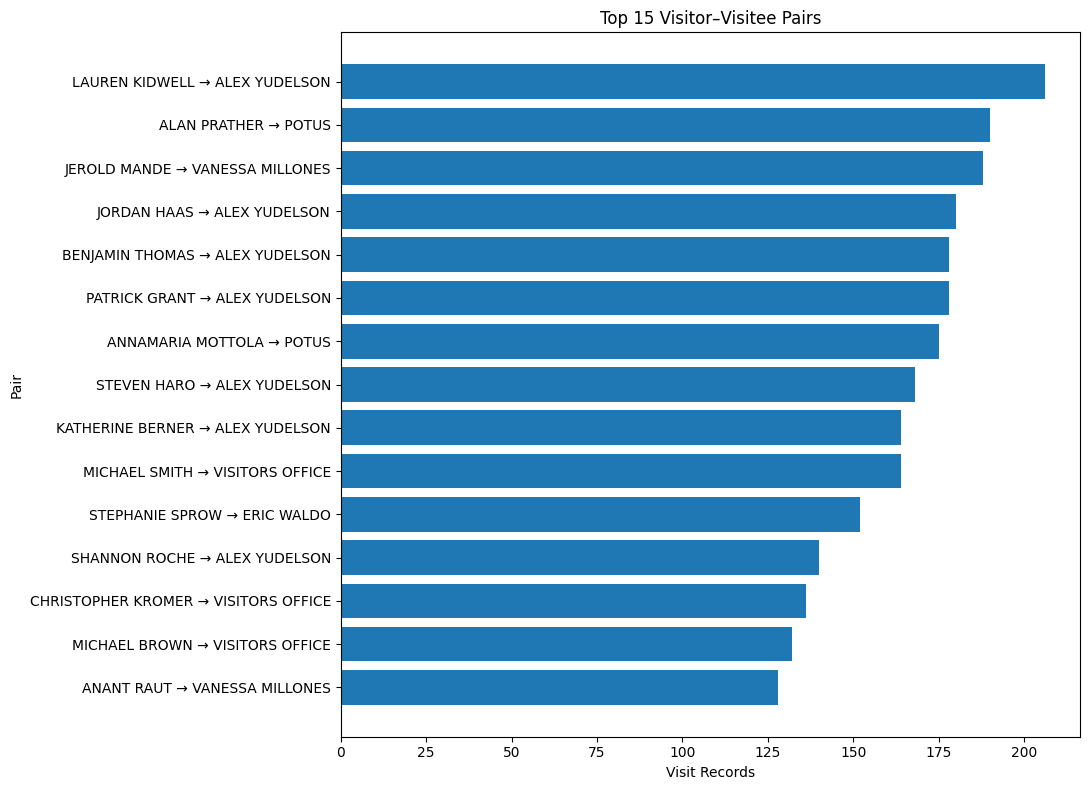

In [26]:
top_pairs = con.execute("""
SELECT v.visitor_name, vt.visitee_name, COUNT(*) AS visits
FROM fact_visit f
JOIN dim_visitor v ON f.visitor_key = v.visitor_key
JOIN dim_visitee vt ON f.visitee_key = vt.visitee_key
GROUP BY 1, 2
ORDER BY visits DESC
LIMIT 15
""").df()

pair_labels = (top_pairs['visitor_name'] + ' → ' + top_pairs['visitee_name']).tolist()

plt.figure(figsize=(11, 8))
plt.barh(pair_labels[::-1], top_pairs['visits'][::-1])
plt.title('Top 15 Visitor–Visitee Pairs')
plt.xlabel('Visit Records')
plt.ylabel('Pair')
plt.tight_layout()
plt.show()


## 7. Twelve OLAP queries


### OLAP 1 — Top-10 visitors

**English question**  
Which 10 visitors appear most often?

**Meaning**  
Counts visit records per visitor.

**Business insight**  
Reveals the highest-frequency visitors.


In [27]:
con.execute("""
SELECT v.visitor_name, COUNT(*) AS visits
FROM fact_visit f
JOIN dim_visitor v ON f.visitor_key = v.visitor_key
GROUP BY 1
ORDER BY visits DESC
LIMIT 10
""").df()


,visitor_name,visits
0,JENNIFER BROWN,413
1,LAUREN KIDWELL,394
2,BENJAMIN THOMAS,358
3,MICHAEL SMITH,350
4,JEROLD MANDE,341
5,KATHERINE BERNER,297
6,PATRICK GRANT,297
7,STEVEN HARO,296
8,ANANT RAUT,257
9,JORDAN HAAS,252


### OLAP 2 — Top-10 visitees

**English question**  
Which 10 visitees receive the most visits?

**Meaning**  
Counts visit records per visitee.

**Business insight**  
Shows the most visited staff contacts.


In [28]:
con.execute("""
SELECT vt.visitee_name, COUNT(*) AS visits
FROM fact_visit f
JOIN dim_visitee vt ON f.visitee_key = vt.visitee_key
GROUP BY 1
ORDER BY visits DESC
LIMIT 10
""").df()


,visitee_name,visits
0,VISITORS OFFICE,1731496
1,POTUS,168455
2,ASHER MAYERSON,48181
3,VISITORSOFFICE WAVES,44255
4,RUTH BRYANT,42018
5,OLIVIA ONEIL,39636
6,COLLIN BURTON,29100
7,JARED THOMPSON,23284
8,POTUS /,22068
9,MATTHEW MEGAN,15914


### OLAP 3 — Top-10 visitor–visitee pairs

**English question**  
Which visitor–visitee relationships occur most often?

**Meaning**  
Counts repeated relationship pairs.

**Business insight**  
Highlights strongest recurring contact patterns.


In [29]:
con.execute("""
SELECT v.visitor_name, vt.visitee_name, COUNT(*) AS visits
FROM fact_visit f
JOIN dim_visitor v ON f.visitor_key = v.visitor_key
JOIN dim_visitee vt ON f.visitee_key = vt.visitee_key
GROUP BY 1, 2
ORDER BY visits DESC
LIMIT 10
""").df()


,visitor_name,visitee_name,visits
0,LAUREN KIDWELL,ALEX YUDELSON,206
1,ALAN PRATHER,POTUS,190
2,JEROLD MANDE,VANESSA MILLONES,188
3,JORDAN HAAS,ALEX YUDELSON,180
4,BENJAMIN THOMAS,ALEX YUDELSON,178
5,PATRICK GRANT,ALEX YUDELSON,178
6,ANNAMARIA MOTTOLA,POTUS,175
7,STEVEN HARO,ALEX YUDELSON,168
8,KATHERINE BERNER,ALEX YUDELSON,164
9,MICHAEL SMITH,VISITORS OFFICE,164


### OLAP 4 — Visits by month

**English question**  
How many visits occur each month?

**Meaning**  
Rolls visit facts up to month level.

**Business insight**  
Supports trend and seasonality analysis.


In [30]:
con.execute("""
SELECT d.year_month, COUNT(*) AS visits
FROM fact_visit f
JOIN dim_date d ON f.date_key = d.date_key
GROUP BY 1
ORDER BY 1
""").df()


,year_month,visits
0,2015-10,243459
1,2015-11,190343
2,2015-12,294085
3,2016-01,150648
4,2016-02,165141
5,2016-03,278094
6,2016-04,213297
7,2016-05,140425
8,2016-06,333081
9,2016-07,281661


### OLAP 5 — Visits by weekday

**English question**  
How are visits distributed across weekdays?

**Meaning**  
Aggregates visits by weekday.

**Business insight**  
Shows work-pattern rhythms.


In [31]:
con.execute("""
SELECT d.weekday_name, COUNT(*) AS visits
FROM fact_visit f
JOIN dim_date d ON f.date_key = d.date_key
GROUP BY 1
ORDER BY visits DESC
""").df()


,weekday_name,visits
0,Friday,597762
1,Saturday,596060
2,Tuesday,469797
3,Thursday,455933
4,Wednesday,409311
5,Monday,175719
6,Sunday,49543


### OLAP 6 — Top locations

**English question**  
Which locations host the most visits?

**Meaning**  
Counts visits by location.

**Business insight**  
Shows where activity is concentrated.


In [32]:
con.execute("""
SELECT l.meeting_loc, COUNT(*) AS visits
FROM fact_visit f
JOIN dim_location l ON f.location_key = l.location_key
GROUP BY 1
ORDER BY visits DESC
LIMIT 10
""").df()


,meeting_loc,visits
0,WH,2298911
1,OEOB,430501
2,NEOB,20521
3,UNKNOWN,2597
4,VPR,1595


### OLAP 7 — Top rooms

**English question**  
Which rooms appear most often?

**Meaning**  
Counts visits at room granularity.

**Business insight**  
Gives a finer-grained facility view.


In [33]:
con.execute("""
SELECT l.meeting_loc, l.meeting_room, COUNT(*) AS visits
FROM fact_visit f
JOIN dim_location l ON f.location_key = l.location_key
GROUP BY 1, 2
ORDER BY visits DESC
LIMIT 15
""").df()


,meeting_loc,meeting_room,visits
0,WH,EW TOUR,1868464
1,WH,SOUTH LAWN,103223
2,WH,State Floo,101352
3,OEOB,SCA,85964
4,WH,WEST WING,80148
5,OEOB,350,31321
6,OEOB,430,27268
7,OEOB,Bowling Al,23715
8,OEOB,South Cour,20715
9,WH,South Lawn,19869


### OLAP 8 — Event descriptions

**English question**  
Which event descriptions are most common?

**Meaning**  
Counts records by description.

**Business insight**  
Shows dominant visit/event categories.


In [34]:
con.execute("""
SELECT e.description, COUNT(*) AS visits
FROM fact_visit f
JOIN dim_event e ON f.event_key = e.event_key
GROUP BY 1
ORDER BY visits DESC
LIMIT 15
""").df()


,description,visits
0,EW Tour Must enter through Sherman Park,1641290
1,UNKNOWN,714449
2,EW Tour Must enter through Sherman Park,175872
3,WEST WING TOUR,78090
4,Duplicate appts Guests cleared on appt U37209 ...,11506
5,General Guests,9373
6,EW Tour Must enter through Sherman Park dob,6660
7,EW Tour Must enter through Sherman Park DOB R...,4977
8,EW Tour Must enter through Sherman Park name,3956
9,NSS Official. Sgt Lillis,3410


### OLAP 9 — Largest total_people footprint

**English question**  
Which visitors are associated with the largest total_people sum?

**Meaning**  
Sums reported group size.

**Business insight**  
Highlights group-heavy activity.


In [35]:
con.execute("""
SELECT v.visitor_name, SUM(COALESCE(f.total_people, 0)) AS people_sum
FROM fact_visit f
JOIN dim_visitor v ON f.visitor_key = v.visitor_key
GROUP BY 1
ORDER BY people_sum DESC
LIMIT 10
""").df()


,visitor_name,people_sum
0,WILLIAM POLK,198307.0
1,MICHAEL SMITH,174214.0
2,KATHERINE JOHNSON,165027.0
3,ELIZABETH KELLY,157863.0
4,STEPHANIE YOUNG,138849.0
5,KATHERINE TAYLOR,136624.0
6,THEODORE LECOMPTE,119788.0
7,WILLIAM JENKINS,113416.0
8,BRIAN ROBERTS,101517.0
9,STEVEN AVILA,100502.0


### OLAP 10 — Average duration by location

**English question**  
How does average visit duration vary by location?

**Meaning**  
Averages visit duration by location.

**Business insight**  
Compares short and long visit settings.


In [36]:
con.execute("""
SELECT l.meeting_loc, AVG(COALESCE(f.visit_duration_minutes, 0)) AS avg_duration_minutes
FROM fact_visit f
JOIN dim_location l ON f.location_key = l.location_key
GROUP BY 1
ORDER BY avg_duration_minutes DESC
LIMIT 10
""").df()


,meeting_loc,avg_duration_minutes
0,NEOB,2256.739584
1,WH,1105.283569
2,OEOB,966.753603
3,UNKNOWN,0.000000
4,VPR,0.000000


### OLAP 11 — Daily activity of top visitors

**English question**  
On which dates were top visitors especially active?

**Meaning**  
Uses visitor-daily aggregate fact.

**Business insight**  
Shows the value of aggregate facts.


In [37]:
con.execute("""
SELECT d.date_key, v.visitor_name, fvd.visit_records
FROM fact_visitor_daily fvd
JOIN dim_date d ON fvd.date_key = d.date_key
JOIN dim_visitor v ON fvd.visitor_key = v.visitor_key
ORDER BY fvd.visit_records DESC
LIMIT 20
""").df()


,date_key,visitor_name,visit_records
0,2015-12-12,MOHAMMAD RAFI,16
1,2015-12-12,MOHAMMAD RAFI,16
2,2015-12-12,MOHAMMAD RAFI,16
3,2015-12-12,MOHAMMAD RAFI,16
4,2016-03-15,JOSEPH KENNEDY,15
5,2015-10-19,ROBERT HICKMOTT,15
6,2016-03-15,JOSEPH KENNEDY,15
7,2016-03-15,JOSEPH KENNEDY,15
8,2015-10-19,ROBERT HICKMOTT,15
9,2016-06-27,JAMES WILLIAMS,14


### OLAP 12 — Daily relationship spikes

**English question**  
Which visitor–visitee pairs spike most on a single day?

**Meaning**  
Uses pair-daily aggregate fact.

**Business insight**  
Connects OLAP with temporal network behavior.


In [38]:
con.execute("""
SELECT d.date_key, v.visitor_name, vt.visitee_name, fpd.visit_records
FROM fact_pair_daily fpd
JOIN dim_date d ON fpd.date_key = d.date_key
JOIN dim_visitor v ON fpd.visitor_key = v.visitor_key
JOIN dim_visitee vt ON fpd.visitee_key = vt.visitee_key
ORDER BY fpd.visit_records DESC
LIMIT 20
""").df()


,date_key,visitor_name,visitee_name,visit_records
0,2015-12-12,MOHAMMAD RAFI,VISITORS OFFICE,4
1,2015-12-12,MOHAMMAD RAFI,VISITORS OFFICE,4
2,2016-07-31,CARLOS FERNANDEZ,ROBINSON GRULLON,4
3,2016-07-31,CARLOS FERNANDEZ,ROBINSON GRULLON,4
4,2015-12-12,MOHAMMAD RAFI,VISITORS OFFICE,4
5,2015-12-12,MOHAMMAD RAFI,VISITORS OFFICE,4
6,2015-12-12,MOHAMMAD RAFI,VISITORS OFFICE,4
7,2015-12-12,MOHAMMAD RAFI,VISITORS OFFICE,4
8,2015-12-12,MOHAMMAD RAFI,VISITORS OFFICE,4
9,2015-12-12,MOHAMMAD RAFI,VISITORS OFFICE,4


## 8. Meeting network analysis

Visitor–visitee pairs can be treated as weighted edges:
- source = visitor
- target = visitee
- weight = number of visit records


In [39]:
network_edges = con.execute("""
SELECT
    v.visitor_name AS source_visitor,
    vt.visitee_name AS target_visitee,
    COUNT(*) AS edge_weight
FROM fact_visit f
JOIN dim_visitor v ON f.visitor_key = v.visitor_key
JOIN dim_visitee vt ON f.visitee_key = vt.visitee_key
GROUP BY 1, 2
ORDER BY edge_weight DESC
LIMIT 30
""").df()

network_edges


,source_visitor,target_visitee,edge_weight
0,LAUREN KIDWELL,ALEX YUDELSON,206
1,ALAN PRATHER,POTUS,190
2,JEROLD MANDE,VANESSA MILLONES,188
3,JORDAN HAAS,ALEX YUDELSON,180
4,BENJAMIN THOMAS,ALEX YUDELSON,178
5,PATRICK GRANT,ALEX YUDELSON,178
6,ANNAMARIA MOTTOLA,POTUS,175
7,STEVEN HARO,ALEX YUDELSON,168
8,KATHERINE BERNER,ALEX YUDELSON,164
9,MICHAEL SMITH,VISITORS OFFICE,164


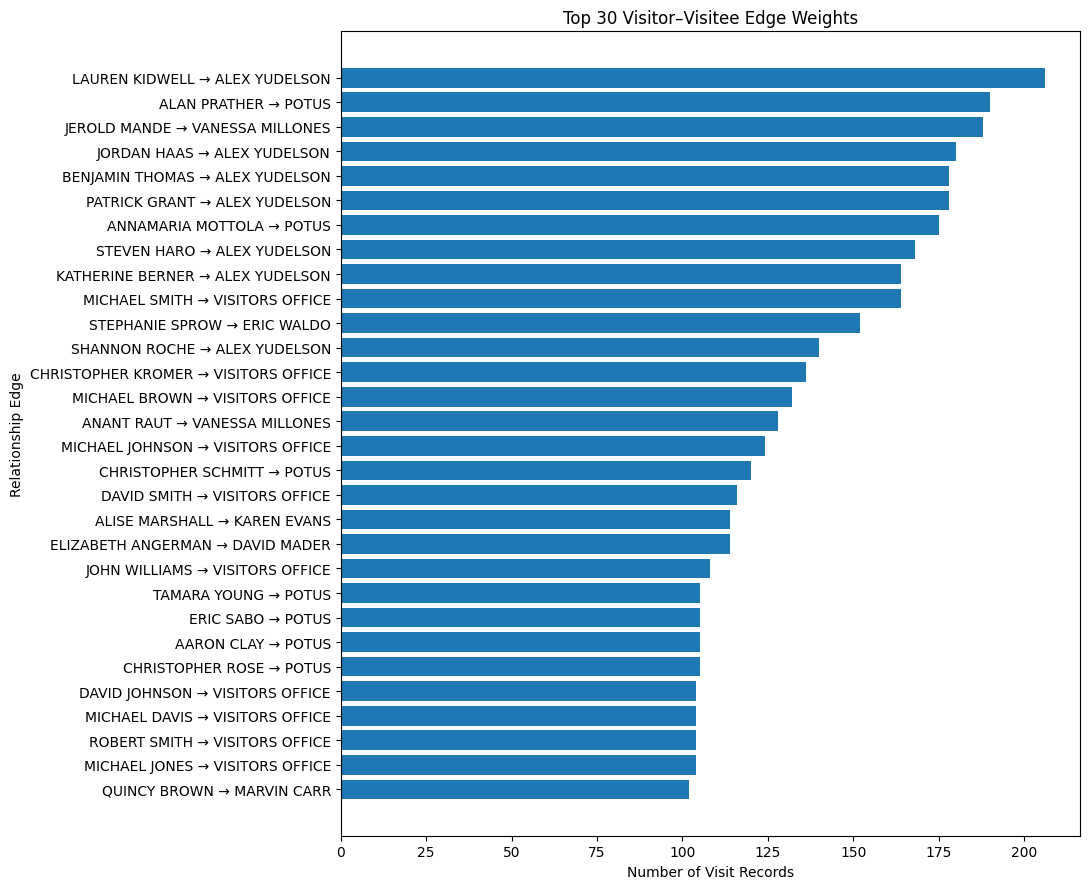

In [40]:
edge_labels = (network_edges['source_visitor'] + ' → ' + network_edges['target_visitee']).tolist()

plt.figure(figsize=(11, 9))
plt.barh(edge_labels[::-1], network_edges['edge_weight'][::-1])
plt.title('Top 30 Visitor–Visitee Edge Weights')
plt.xlabel('Number of Visit Records')
plt.ylabel('Relationship Edge')
plt.tight_layout()
plt.show()


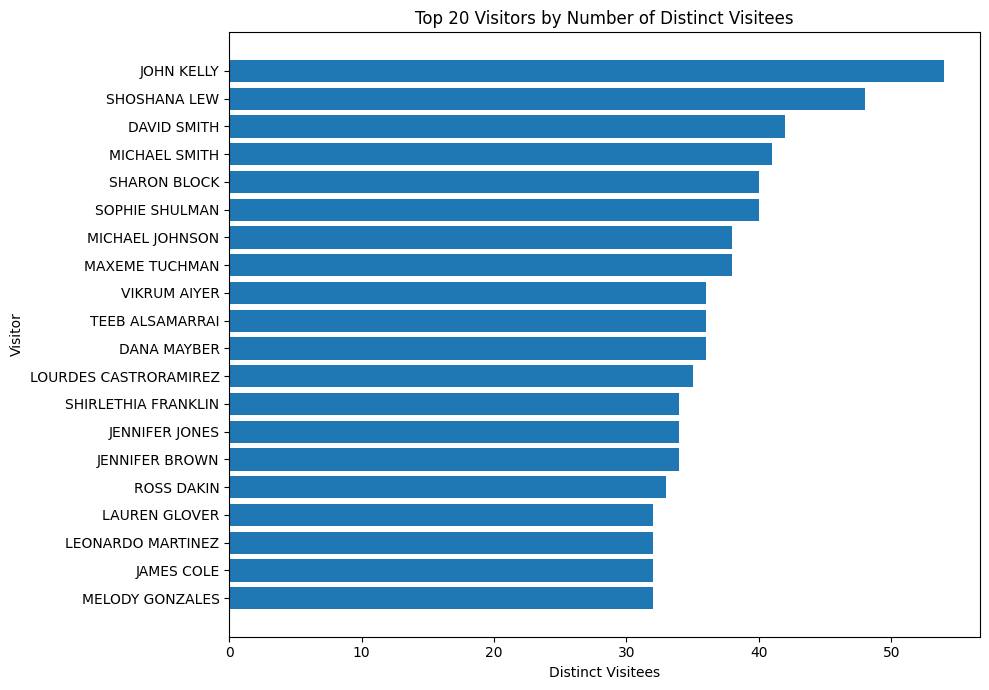

In [41]:
visitor_degree = con.execute("""
SELECT v.visitor_name, COUNT(DISTINCT vt.visitee_name) AS distinct_visitees
FROM fact_visit f
JOIN dim_visitor v ON f.visitor_key = v.visitor_key
JOIN dim_visitee vt ON f.visitee_key = vt.visitee_key
GROUP BY 1
ORDER BY distinct_visitees DESC
LIMIT 20
""").df()

plt.figure(figsize=(10, 7))
plt.barh(visitor_degree['visitor_name'][::-1], visitor_degree['distinct_visitees'][::-1])
plt.title('Top 20 Visitors by Number of Distinct Visitees')
plt.xlabel('Distinct Visitees')
plt.ylabel('Visitor')
plt.tight_layout()
plt.show()


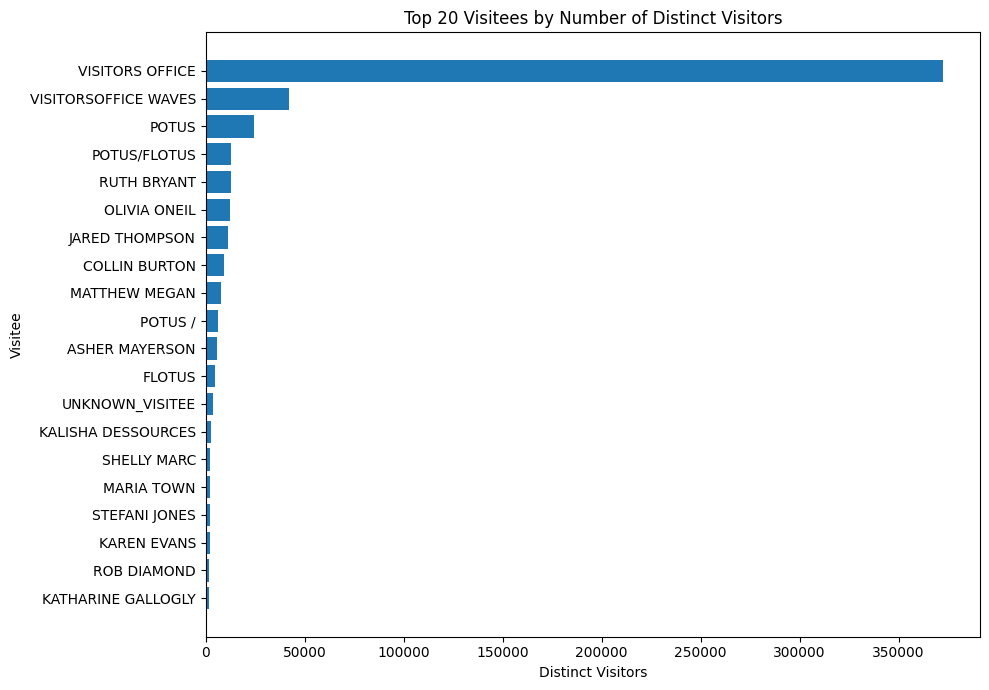

In [42]:
visitee_degree = con.execute("""
SELECT vt.visitee_name, COUNT(DISTINCT v.visitor_name) AS distinct_visitors
FROM fact_visit f
JOIN dim_visitor v ON f.visitor_key = v.visitor_key
JOIN dim_visitee vt ON f.visitee_key = vt.visitee_key
GROUP BY 1
ORDER BY distinct_visitors DESC
LIMIT 20
""").df()

plt.figure(figsize=(10, 7))
plt.barh(visitee_degree['visitee_name'][::-1], visitee_degree['distinct_visitors'][::-1])
plt.title('Top 20 Visitees by Number of Distinct Visitors')
plt.xlabel('Distinct Visitors')
plt.ylabel('Visitee')
plt.tight_layout()
plt.show()


## 9. Final summary

This notebook shows how:
- EDA informs Medallion decisions
- Bronze preserves the source
- Silver creates clean analysis-ready events
- Gold creates a reusable warehouse
- OLAP and network-style analysis both benefit from the same warehouse foundation
